In [2]:
import json
import rich

In [3]:
with open("llama3.1_8b_lora.json", 'r') as f:
    llama_8b_lora = json.load(f)
    
with open("llama3_8b_finetune_actual.json", 'r') as f:
    actual = json.load(f)
    
with open("llama3.1_70b.json", 'r') as f:
    llama_70b = json.load(f)
    
with open("llama3.1_8b.json", 'r') as f:
    llama_8b = json.load(f)
    
countries_list = ['Austria', 'England', 'France', 'Germany', 'Italy', 'Russia', 'Turkey']

In [7]:
len(llama_8b_lora), len(actual), len(llama_70b), len(llama_8b)

(482, 482, 482, 482)

In [5]:
def remove_duplicates_by_uuid(dict_list, uuid_key='env_uuid'):
    seen = set()
    unique_list = []
    
    for d in dict_list:
        uuid_value = d.get(uuid_key)
        if uuid_value and uuid_value not in seen:
            seen.add(uuid_value)
            unique_list.append(d)
    
    return unique_list

In [6]:
actual = remove_duplicates_by_uuid(actual)
print(len(actual))
# llama = llama[:141]
# print(len(llama))

482


In [8]:
def get_score_with_env(countries, prediction):
    scores = 0
    for c in countries:
        scores += prediction[c][c.upper()][1]
    score_dict = {}
    score_dict['env'] = prediction['env_uuid']
    score_dict['scores'] = scores / len(countries)
    return score_dict

def get_score_dict_from_dialogue(dialogue):
    score_list = []
    for a in dialogue:
        if a['intent_dialogue'] == "":
            continue
        keys = []
        for vkeys in a.keys():
            if vkeys in countries_list:
                keys.append(vkeys)
        score_list.append(get_score_with_env(keys, a))
    return score_list

In [9]:
llama_8b_lora_scores = get_score_dict_from_dialogue(llama_8b_lora)
actual_scores = get_score_dict_from_dialogue(actual)
llama_70b_scores = get_score_dict_from_dialogue(llama_70b)
llama_8b_scores = get_score_dict_from_dialogue(llama_8b)

In [10]:
len(llama_8b_lora_scores), len(actual_scores), len(llama_70b_scores), len(llama_8b_scores)

(429, 316, 438, 419)

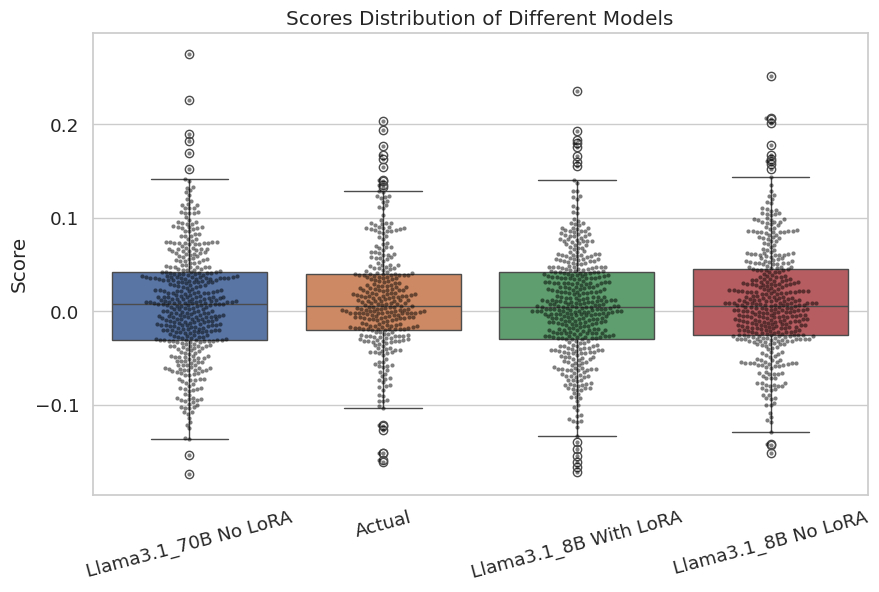

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# TODO: add comparison between human and actual movement
# data1 = [d['scores'] for d in human_few_shot_score_dict if d['scores'] >= 0.06]
data1 = [d['scores'] for d in llama_8b_lora_scores]
data2 = [d['scores'] for d in actual_scores]
data3 = [d['scores'] for d in llama_70b_scores]
data4 = [d['scores'] for d in llama_8b_scores]
sns.set(style="whitegrid", font_scale=1.2)

# 将数据打包进一个列表中，后续配合labels
all_data = [data3, data2, data1, data4]
labels = ['Llama3.1_70B No LoRA', 'Actual', 'Llama3.1_8B With LoRA', 'Llama3.1_8B No LoRA']

plt.figure(figsize=(10, 6))
sns.boxplot(data=all_data)
sns.swarmplot(data=all_data, color='black', alpha=0.5, size=3)  # 叠加一个散点，增加细节

plt.xticks(range(len(labels)), labels, rotation=15)
plt.title('Scores Distribution of Different Models')
plt.ylabel('Score')
plt.show()


/tmp/ipykernel_1173682/2826838206.py:13: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data3, shade=True, color='purple', ax=axes[0,0])
/tmp/ipykernel_1173682/2826838206.py:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data2, shade=True, color='skyblue', ax=axes[0,1])
/tmp/ipykernel_1173682/2826838206.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data1, shade=True, color='green', ax=axes[1,0])
/tmp/ipykernel_1173682/2826838206.py:22: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data4, sh

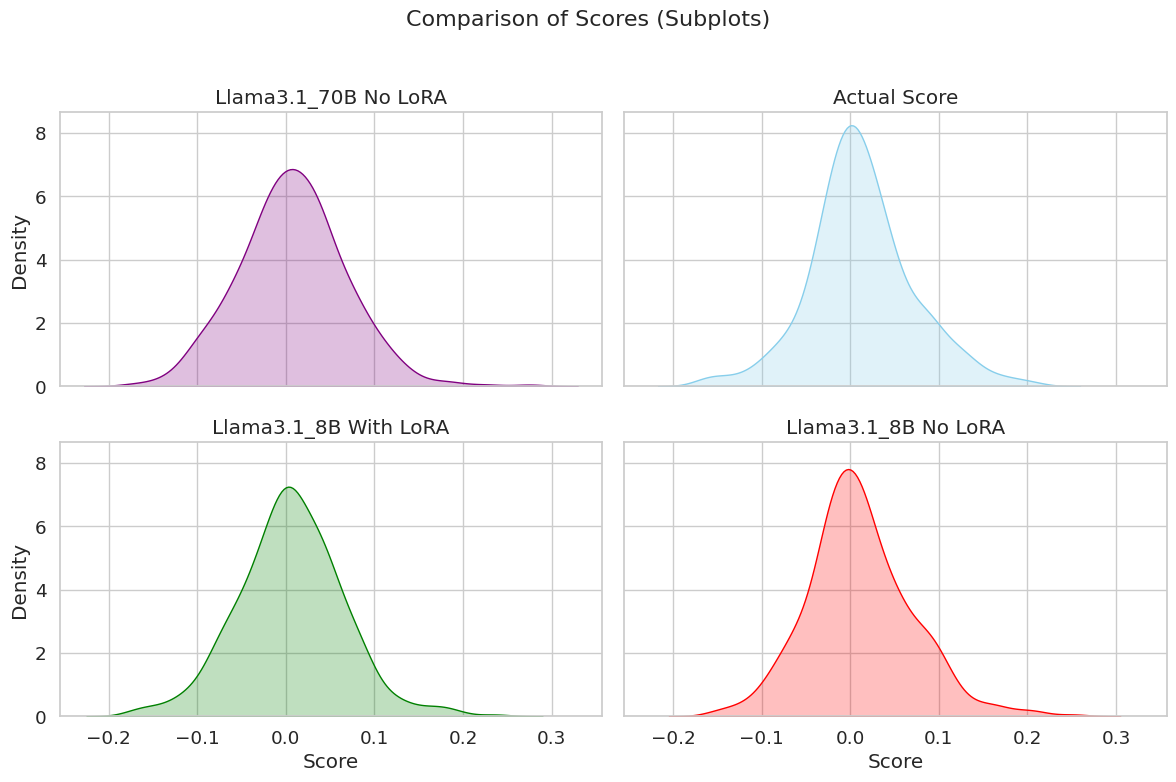

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
data1 = [d['scores'] for d in llama_8b_lora_scores]
data2 = [d['scores'] for d in actual_scores]
data3 = [d['scores'] for d in llama_70b_scores]
data4 = [d['scores'] for d in llama_8b_scores]
sns.set(style="whitegrid", font_scale=1.2)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
fig.suptitle('Comparison of Scores (Subplots)', fontsize=16)

axes[0,0].set_title('Llama3.1_70B No LoRA')
sns.kdeplot(data3, shade=True, color='purple', ax=axes[0,0])

axes[0,1].set_title('Actual Score')
sns.kdeplot(data2, shade=True, color='skyblue', ax=axes[0,1])

axes[1,0].set_title('Llama3.1_8B With LoRA')
sns.kdeplot(data1, shade=True, color='green', ax=axes[1,0])

axes[1,1].set_title('Llama3.1_8B No LoRA')
sns.kdeplot(data4, shade=True, color='red', ax=axes[1,1])

for ax in axes.flat:
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # 调整子图与标题布局
plt.show()


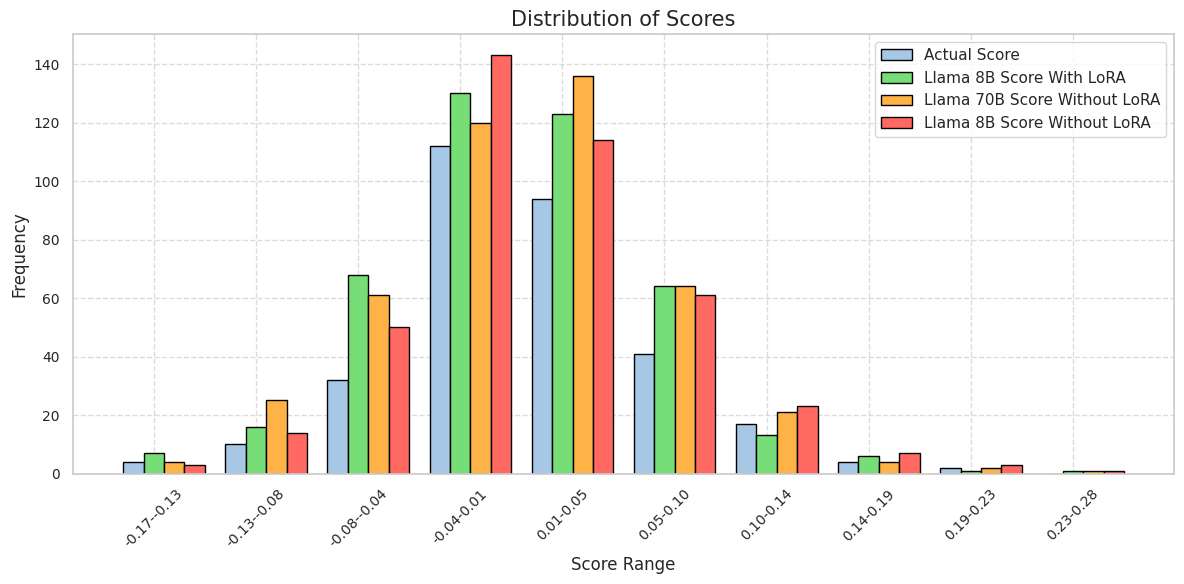

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 提取每组数据中的分数
data1 = [d['scores'] for d in actual_scores]
data2 = [d['scores'] for d in llama_8b_lora_scores]
data3 = [d['scores'] for d in llama_70b_scores]
data4 = [d['scores'] for d in llama_8b_scores]

# 合并所有数据以确定分数范围
all_data = data1 + data2 + data3

# 设置分数区间的个数（例如10个区间）
num_bins = 10
bins = np.linspace(min(all_data), max(all_data), num_bins + 1)

# 分别计算各组数据在各区间内的频数
counts1, _ = np.histogram(data1, bins=bins)
counts2, _ = np.histogram(data2, bins=bins)
counts3, _ = np.histogram(data3, bins=bins)
counts4, _ = np.histogram(data4, bins=bins)

# 为每个区间创建标签，例如 "0.00-0.10"
bin_labels = [f"{bins[i]:.2f}-{bins[i+1]:.2f}" for i in range(len(bins) - 1)]

# 使用整数作为x轴分组位置，每个分数段对应一个位置
x = np.arange(len(bin_labels))
width = 0.20  # 每个柱子的宽度

plt.figure(figsize=(12, 6))
# 使用浅色系的配色方案
plt.bar(x - width, counts1, width=width, label='Actual Score', color='#A7C7E7', edgecolor='black')
plt.bar(x, counts2, width=width, label='Llama 8B Score With LoRA', color='#77DD77', edgecolor='black')
plt.bar(x + width, counts3, width=width, label='Llama 70B Score Without LoRA', color='#FFB347', edgecolor='black')
plt.bar(x + 2 * width, counts4, width=width, label='Llama 8B Score Without LoRA', color='#FF6961', edgecolor='black')

plt.xlabel('Score Range', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Scores', fontsize=15)
plt.xticks(x, bin_labels, rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


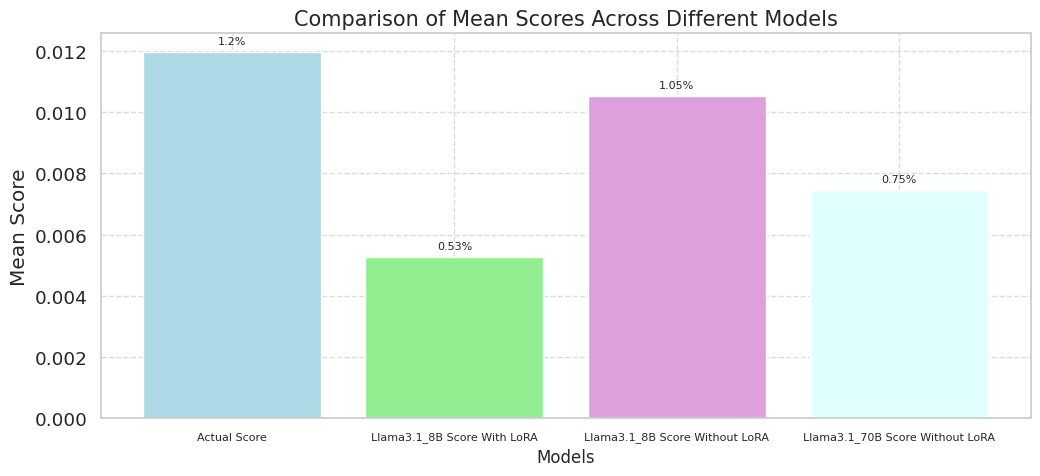

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 提取每组数据中的分数
data1 = [d['scores'] for d in actual_scores]
data2 = [d['scores'] for d in llama_8b_lora_scores]
data3 = [d['scores'] for d in llama_8b_scores]
data4 = [d['scores'] for d in llama_70b_scores]

mean1 = np.mean(data1)
mean2 = np.mean(data2)
mean3 = np.mean(data3)
mean4 = np.mean(data4)

labels = [
    'Actual Score', 
    'Llama3.1_8B Score With LoRA', 
    'Llama3.1_8B Score Without LoRA', 
    'Llama3.1_70B Score Without LoRA'
]
means = [mean1, mean2, mean3, mean4]

# 设置颜色
colors = ['lightblue', 'lightgreen', 'plum', 'lightcyan']

plt.figure(figsize=(12, 5))
bars = plt.bar(labels, means, color=colors)

# 调整 x 轴刻度字体大小
plt.xticks(fontsize=8)

# 在 bar 上方标数字，并让它更贴近柱顶
for bar in bars:
    height = bar.get_height()
    score_percent = round(height * 100, 2)  # 转成百分比
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        height + 0.0002,          # 将偏移量设小一点，让数字紧贴柱顶
        f'{score_percent}%', 
        ha='center', 
        va='bottom',
        fontsize=8               # 如果想让上面的文字也更小，可以在这里设 fontsize
    )

plt.title('Comparison of Mean Scores Across Different Models', fontsize=15)
plt.xlabel('Models', fontsize=12)   
plt.ylabel('Mean Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [25]:
for s in store_pair:
    li = s[0]
    loi = s[1]
    rich.print(f"[bold blue]Llama Dialogue:[/bold blue]\n{li}\n\n[bold magenta]Llama LoRA Dialogue:[/bold magenta]\n{loi}")

Llama Dialogue:
0 RUSSIA -> AUSTRIA: So, Russia will be moving to Rumania, Rumania moves to Sev with support from Armenia, Black 
Sea supports Constantinople to Bulgaria. Does this plan sound reasonable to you?
1 RUSSIA -> AUSTRIA: I think that's a good plan. I'll also move my army from Ukraine to Warsaw, to protect against 
Germany's build in Berlin. What do you think about that?
2 AUSTRIA -> RUSSIA: I like the plan to move to Rumania, Rumania to Sev with support from Armenia, Black Sea 
supports Constantinople to Bulgaria. It seems like a good strategy to secure our positions. However, I'm a bit 
concerned about Austria's potential moves. Have you considered how they might react to our plans?
3 RUSSIA -> AUSTRIA: I'm glad we could come to an agreement on the plan. I think it's a good strategy to secure our
positions. However, I'm a bit concerned about Austria's potential moves. Have you considered how they might react 
to our plans? And do you think they will support our moves or not?

Llama LoRA Dialogue:
0 AUSTRIA -> RUSSIA: So where is Serbia going now?
1 RUSSIA -> AUSTRIA: I'm happy to discuss the future of our board position. Considering the current situation, I 
think Serbia moving to Rumania would be beneficial for both of us. How do you feel about that?

Llama Dialogue:
0 RUSSIA -> TURKEY: I think our previous plan is still a good one. What are your thoughts on moving Rum to Sev this
turn and Armenia to Bulgaria?
1 TURKEY -> RUSSIA: Your previous plan was sound, but I think we should also consider other options to secure our 
positions. What do you think about supporting my move into Bulgaria this turn? It could help us gain a stronger 
foothold in the region.
2 RUSSIA -> TURKEY: I think supporting your move into Bulgaria this turn is a good idea. It would help us gain a 
stronger foothold in the region. However, I'm also considering moving Rum to Sev this turn and Armenia to Bulgaria.
What do you think about these options?
3 TURKEY -> RUSSIA: I like the idea of supporting your move into Bulgaria this turn. It would be beneficial for our
position in the region. However, I also think we should consider other options to secure our positions. What do you
think about moving Rum to Sev this turn and Armenia to Bulgaria? It could give us a stronger foothold in the 
region.
4 RUSSIA -> TURKEY: I think supporting your move into Bulgaria this turn is a good idea. Additionally, I'd like to 
propose a plan to secure our positions in the region. What are your thoughts on moving Rum to Sev this turn and 
Armenia to Bulgaria? It could give us a stronger foothold in the region.

Llama LoRA Dialogue:
0 TURKEY -> RUSSIA: Russia, I think we should discuss our plans for this turn. I've been considering supporting 
Rumelia to Bulgaria, do you think that's a good idea?
1 RUSSIA -> TURKEY: I appreciate your consideration of supporting Rumelia to Bulgaria. Considering the current 
situation, I think it's a good idea. It will allow us to gain a foothold in Bulgaria and put pressure on Austria. 
Additionally, it will give us a chance to bounce Austria's army in Bulgaria, which could be beneficial in the long 
run. What do you think about supporting my army in Sevastopol to Rumania as well? It would help us to secure our 
position in the Black Sea and potentially open up opportunities for future expansion.
2 TURKEY -> RUSSIA: I think supporting Rumelia to Bulgaria is a great idea. It will definitely put pressure on 
Austria and give us a foothold in Bulgaria. As for your suggestion to support your army in Sevastopol to Rumania, I
think it's a good idea too. It will help us to secure our position in the Black Sea and potentially open up 
opportunities for future expansion. However, I'm a bit concerned about Austria's army in Bulgaria. Do you think we 
should try to bounce it this turn or wait for next turn?
3 RUSSIA -> TURKEY: I appreciate your consideration of supporting Rumelia to Bulgaria. Considering the current 
situation, I think it's a good idea. It will allow us to gain a foothold in Bulgaria and put pressure on Austria. 
Additionally, it will give us a chance to bounce Austria's army in Bulgaria, which could be beneficial in the long 
run. What do you think about supporting my army in Sevastopol to Rumania as well? It would help us to secure our 
position in the Black Sea and potentially open up opportunities for future expansion.
4 TURKEY -> RUSSIA: I like the idea of supporting Rumelia to Bulgaria and Sevastopol to Rumania. It will help us to
secure our position in the Black Sea and potentially open up opportunities for future expansion. What do you think 
about our plan, and are there any other moves you'd like to make this turn?
5 RUSSIA -> TURKEY: Turkey, considering our previous discussion, I think supporting Rumelia to Bulgaria is a good 
idea. Additionally, I'd like to propose supporting my army in Sevastopol to Rumania as well, to secure our position
in the Black Sea and potentially open up opportunities for future expansion.
6 RUSSIA -> TURKEY: I like the idea of supporting Rumelia to Bulgaria and Sevastopol to Rumania. It will help us to
secure our position in the Black Sea and potentially open up opportunities for future expansion. What do you think 
about our plan, and are there an

Llama Dialogue:
0 FRANCE -> RUSSIA: I'm happy to discuss our board position and any potential moves that could benefit both of our 
situations. I see you're supporting Tyrolia to hold, which is a good move. What are your thoughts on the current 
state of our border and any potential threats or opportunities we could address together?
1 RUSSIA -> FRANCE: I'm glad to discuss our board position and any potential moves that could benefit both of our 
situations. I notice that you're supporting Tyrolia to hold, which is a good move. What are your thoughts on the 
current state of our border and any potential threats or opportunities we could address together?

Llama LoRA Dialogue:
0 FRANCE -> RUSSIA: Russia, I'm happy that we're still on good terms. As you know, I'm looking to control 18 or 
more supply centers by the end of the game. Considering our previous discussions, I'm curious to know if you're 
willing to support me in Munich this turn. It would really help me out and allow me to focus on other parts of my 
board.
1 RUSSIA -> FRANCE: I appreciate your offer, France. However, I'm not sure if supporting you in Munich this turn 
would be beneficial for my board position. Could you explain how this move would help me achieve my goal of 
controlling 18 or more supply centers by the end of the game?
2 FRANCE -> RUSSIA: I appreciate your caution, Russia. Considering our previous discussions, I'm willing to propose
a different solution that could benefit both of our boards. I could support your move into Venice this turn, which 
would help you gain a foothold in Italy. In return, I would expect you to support my move into Munich, which would 
help me secure a crucial center. What do you think about this proposal?
3 RUSSIA -> FRANCE: France, I appreciate your offer to support my move into Venice this turn. I'm considering it, 
but I'd like to discuss the implications of it on my board position. How do you think it would affect our overall 
situation?
4 FRANCE -> RUSSIA: I'm glad we're discussing the situation, Russia. I think supporting each other's moves can 
really benefit our boards. I'll reiterate my previous offer: I'll support your move into Venice if you support my 
move into Munich. What do you think?

Llama Dialogue:
0 RUSSIA -> TURKEY: I don't want to limit your growth, I'll support you instead. How about supporting my army move 
from RUM to BUD? It would help me secure a key center and solidify my position in the region. What do you think?
1 TURKEY -> RUSSIA: I appreciate your willingness to support me, Russia. Supporting your RUM to BUD move could be 
beneficial for both of us. However, I'd like to focus on securing my own position first. I'm interested in knowing 
more about your plans for this turn and if there are any specific moves you'd like us to support each other with.
2 TURKEY -> RUSSIA: I'm willing to support your army move from RUM to BUD, but I'd like to know more about your 
plans for this turn and if there are any specific moves you'd like us to support each other with. Perhaps we can 
discuss other ways to strengthen our positions in the region, such as supporting a move from TRI to VEN?
3 RUSSIA -> TURKEY: I see that you're interested in supporting my RUM to BUD move. That's great! In return, I can 
support your TRI to VEN move. It would be beneficial for both of us to secure our positions in the region. What do 
you think about this proposal?
4 TURKEY -> RUSSIA: I'm interested in your suggestion, Russia. Supporting your RUM to BUD move could be beneficial 
for both of us. However, I'd like to clarify that I'm not sure if it's the best move for me. Could you provide more
information about why you think it's a good idea, and what you think the consequences of not supporting it would 
be?
5 RUSSIA -> TURKEY: I'm glad we're discussing this, Turkey. Supporting my RUM to BUD move would help me secure a 
key center and solidify my position in the region. It's a crucial move for me this turn, and I think it would be 
beneficial for both of us if we work together. What do you think about the move, and are there any other ways we 
can support each other this turn?

Llama LoRA Dialogue:
0 TURKEY -> RUSSIA: I'm glad we're having this conversation. I was thinking about supporting your army in TRI to 
VEN. It would help secure your southern border and give you more options for future moves. What do you think?
1 RUSSIA -> TURKEY: I appreciate your willingness to support my army in TRI to VEN. However, I'm not sure it's the 
best move for me this turn. I'm still evaluating my options. Can you tell me more about your motivations for 
supporting me and what you hope to gain from this alliance?
2 TURKEY -> RUSSIA: That's a good point, and I appreciate your honesty. I was thinking about supporting your army 
in TRI to VEN as well. However, I'm not sure if it would be the best move for me this turn. I have some other 
options in mind that could potentially benefit my board position. Can you tell me more about your goals and what 
you're trying to achieve this turn?
3 RUSSIA -> TURKEY: I appreciate your willingness to support my army in TRI to VEN. It shows that you're thinking 
ahead and considering the long game. However, I'm still evaluating my options and I need to consider the potential 
consequences of moving my army to VEN this turn. Can you tell me more about your motivations for supporting me and 
what you hope to gain from this alliance?

Llama Dialogue:
0 ITALY -> AUSTRIA: I think we should support Italy's move to Greece with Ionian, because they will probably cut 
Serbia's support but it's up to you of course
1 AUSTRIA -> ITALY: I think attacking Greece is a good idea. Italy, can you support my attack with Ionian? This 
would allow me to take Serbia and then potentially move west.
2 AUSTRIA -> ITALY: I think the plan to attack Greece with Bulgaria and Serbia is a good one. Italy, can you 
support my attack with Ionian as well?
3 AUSTRIA -> ITALY: I agree with Italy, supporting Italy's move to Greece with Ionian is a good idea. Italy, can 
you support my attack with Ionian as well? This would allow me to take Serbia and then potentially move west.
4 ITALY -> AUSTRIA: I think that's a great plan! I'll support Italy's move to Greece with Ionian. This way, we can 
cut Serbia's support and gain more ground in the Balkans.
5 AUSTRIA -> ITALY: I agree with Italy. Supporting Italy's move to Greece with Ionian is a good idea. Italy, can 
you support my attack with Ionian as well? This would allow me to take Serbia and then potentially move west.
6 ITALY -> AUSTRIA: That sounds like a good plan. I'll support Italy's move to Greece with Ionian. This will give 
us a good chance to take out Russia.

Llama LoRA Dialogue:
0 AUSTRIA -> ITALY: Italy, I was thinking about supporting Russia in Rum, but I'm open to alternative ideas. What 
do you think about the current situation and how we can work together to achieve our goals?
1 ITALY -> AUSTRIA: hmm probably not...but a strong turkey is not also good for us...
2 AUSTRIA -> ITALY: Do you think it would be a good idea to support Russia in Rum, or do you have a different plan 
in mind?
3 ITALY -> AUSTRIA: ok, great i will move there...i will attack the aegean, you can attack Gal and Rum, so probably
i will enter in greece
4 AUSTRIA -> ITALY: I think that's a great idea to attack the Aegean, Italy. However, I was also thinking of 
supporting Russia in Gal and Rum. What do you think about this plan? And how do you plan to proceed with your units
after attacking the Aegean?

...

Llama Dialogue:
0 TURKEY -> ITALY: I am glad we are discussing our next moves. Your previous suggestion of ION-GRE, AEG S ION-GRE, 
RUM-BUD, SER S RUM-BUD, TRI-VIE, GAL S TRI-VIE looks promising. I would like to confirm if these moves are still 
viable and if there are any changes you would like to make. Additionally, I am curious if you have considered our 
chances of taking all of Austria's SC in one shot. If so, what are your thoughts on this?
1 TURKEY -> ITALY: I like the way you're thinking, Italy. Taking all of Austria's SC in one shot would be 
incredible. However, I'm concerned about the possibility of Austria making a comeback. Have you thought about a 
contingency plan in case things don't go as smoothly as we hope?
2 ITALY -> TURKEY: I think that's a great idea, Turkey. Let's go with the original plan and see how it unfolds. If 
things don't go as smoothly as we hope, we can always adjust our strategy. I'm open to any suggestions you might 
have.

Llama LoRA Dialogue:
0 TURKEY -> ITALY: It seems that you have proposed a plan to take out Austria quickly and then turn our attention 
towards England-France. I like the idea of striking quickly and decisively. I think we should try to take out 
Greece instead of Budapest, as you suggested. That way, we can gain more territory and put pressure on Austria. 
What do you think?
1 ITALY -> TURKEY: ok perfect. Lets do it the way you proposed it.
2 TURKEY -> ITALY: I agree with your plan, let's go with the moves you suggested. ION-GRE, AEG S ION-GRE, RUM-BUD, 
SER S RUM-BUD, TRI-VIE, GAL S TRI-VIE. This way we have a chance at taking all of Austria's SC in one shot. Odds 
are not all will fall but 3 for sure.

Llama Dialogue:
0 ITALY -> TURKEY: I realize you are kind of boxed in with your fleets, but I'm just curious as to your plans for 
the fleet in Ionian? As you can surely understand, I am somewhat nervous seeing as how it is threatening an 
unmanned center of mine.
1 TURKEY -> ITALY: I understand your concern. If you support my unit into Serb, I'll move my unit back and give you
time to get units there. Let me know your plan.
2 ITALY -> TURKEY: That sounds like a good plan. Trieste will support Bulgaria to Serbia. I'll make sure to move my
units accordingly.
3 TURKEY -> ITALY: I think our agreement will work out well. I'll make sure to support Bulgaria to Serbia. Let's 
keep an eye on the situation and adjust our plans as needed.
4 ITALY -> TURKEY: I'm glad we're on the same page with our agreement. I think it's crucial for us to keep an eye 
on the situation and adjust our plans accordingly. Do you think Russia and Turkey's alliance will pose a 
significant threat to our position?

Llama LoRA Dialogue:
0 TURKEY -> ITALY: I appreciate your willingness to negotiate, Italy. I was thinking of moving my Ionian fleet. 
What are your thoughts on supporting my unit into Serbia?
1 ITALY -> TURKEY: I'd be happy to support your unit into Serbia, Turkey. However, I have some concerns about your 
Ionian fleet. Are you considering moving it to support Turkey's units in the region or do you have another plan in 
mind?

Llama Dialogue:
0 TURKEY -> AUSTRIA: Actually, I think a better plan would be to move Smyrna to Ankara and support it with 
Sevastopol. This way, we can keep pressure on Russia and also have a possible route to the Mediterranean. What do 
you think about this plan?
1 AUSTRIA -> TURKEY: I think that's a great plan, but before we do that, I'd like to discuss another possibility. 
Are you open to supporting me into Rumania this turn? It would give us a stronger position in the board.
2 TURKEY -> AUSTRIA: That sounds like a good plan, but before we move Smyrna to Ankara, I'd like to discuss another
possibility. Are you open to supporting me into Bulgaria this turn? It would give us a stronger position in the 
board.
3 AUSTRIA -> TURKEY: I think that's a great plan, but before we move Smyrna to Ankara, I'd like to discuss another 
possibility. Are you open to supporting me into Rumania this turn? It would give us a stronger position in the 
board.
4 TURKEY -> AUSTRIA: I think supporting Austria into Rumania this turn would be a good idea. It would give us a 
stronger position in the board and potentially open up new opportunities for us. What do you think about this plan?
5 AUSTRIA -> TURKEY: I think your plan to move Smyrna to Ankara and support it with Sevastopol is a good one, but 
I'd like to discuss another possibility. Are you open to supporting me into Rumania this turn? It would give us a 
stronger position in the board and potentially open up new opportunities for us.
6 TURKEY -> AUSTRIA: I think supporting Austria into Rumania this turn would be a good idea. It would give us a 
stronger position in the board and potentially open up new opportunities for us. What do you think about this plan?
7 AUSTRIA -> TURKEY: I think supporting you into Bulgaria this turn would be a great idea. It would give us a 
stronger position in the board and potentially open up new opportunities for us. What do you think about this plan?
I'm also considering moving my army to Rumania to support you. Let me know if that's something you'd be interested 
in.
8 TURKEY -> AUSTRIA: I think you're right that supporting Austria into Rumania this turn would be a good idea. It 
would give us a stronger position in the board and potentially open up new opportunities for us. But before we do 
that, I'd like to make sure that you're not planning on moving any units that would put us in a worse position. Can
you tell me your plans for this turn?

Llama LoRA Dialogue:
0 TURKEY -> AUSTRIA: Yeah, I'm still debating what to do here. I probably need to cover Constantinople, so that may
change my plans...
1 TURKEY -> AUSTRIA: I was thinking of supporting your army in Rumania, and also supporting Smyrna. What are your 
thoughts on that?
2 AUSTRIA -> TURKEY: I think supporting Rumania would be a good idea. It would help me gain a foothold in the 
Balkans and give me a better chance of expanding into Serbia or Bulgaria in the future. Additionally, supporting 
Smyrna would help to secure your position in the Aegean and prevent any potential English or Russian threats in 
that region.
3 TURKEY -> AUSTRIA: I was thinking of supporting your army in Rumania, and also supporting Smyrna. What are your 
thoughts on that?
4 AUSTRIA -> TURKEY: I like your idea of supporting my army in Rumania and Smyrna. It would definitely help to 
secure my position in the Balkans and prevent any potential English or Russian threats in that region. How do you 
think we can work together to achieve our goals in the next few turns?

Llama Dialogue:
0 ENGLAND -> GERMANY: I can consent to you taking Norway this turn, though I don't know how many other centers you 
anticipate gaining. I anticipate netting 1 without you taking Norway, and so would net 0 with you taking Norway, 
just FYI for keeping our growth even.
1 GERMANY -> ENGLAND: I think holding off on taking Norway this turn is a good idea, considering the uncertainty 
with Turkey and the potential for a stronger position in the future. I'm open to discussing other options that 
could benefit both our boards.
2 ENGLAND -> GERMANY: I'm glad we're on the same page about holding off on taking Norway this turn. Have you given 
any thought to our previous discussion about a potential trade? Perhaps we could revisit the idea of you taking Nwy
in exchange for Bur S Pic-par? That could set up some interesting possibilities for our boards moving forward.
3 GERMANY -> ENGLAND: I'm glad we're considering the possibility of Bur S Pic-par. However, I'm still unsure about 
the potential benefits and drawbacks of this move. Could you elaborate on your thoughts and help me better 
understand the implications?
4 ENGLAND -> GERMANY: I'm glad we're on the same page about holding off on taking Norway this turn. Now that we've 
discussed the trade idea, I'd like to propose a different option. What do you think about me moving A Pic to Par, 
and then you moving F Swe to Nwy? This could create some opportunities for us in the future.
5 GERMANY -> ENGLAND: I'm still not convinced that holding off on taking Norway is the best idea, considering the 
potential benefits of taking it this turn. Let's discuss some alternative options that could benefit our boards.

Llama LoRA Dialogue:
0 ENGLAND -> GERMANY: I'm glad we were able to come to an agreement on Germany taking Norway this turn, Germany. 
Now that's settled, I'd like to discuss our next moves. I was thinking of moving my army from Pic to Par, and my 
fleet from Mao to Por. What are your thoughts on these moves?
1 ENGLAND -> GERMANY: I'm glad we were able to come to an agreement on Germany taking Norway this turn, Germany. 
Now that's settled, I'd like to discuss our next moves. I was thinking of moving my army from Pic to Par, and my 
fleet from Mao to Por. What are your thoughts on these moves?
2 ENGLAND -> GERMANY: I think moving Pic to Par and Mao to Por are solid moves, Germany. That would give us good 
control of the board and set us up for future expansion. What do you think about our army movements this turn?
3 GERMANY -> ENGLAND: I think moving Pic to Par and Mao to Por are solid moves. It would give us good control of 
the board and set us up for future expansion. What do you think about our army movements this turn?

Llama Dialogue:
0 TURKEY -> ITALY: I think it's a good idea to support you to Vienna this turn, as you mentioned earlier. It will 
likely have the same results as taking Rum this turn, but it will also give us a strong position for next turn. 
Plus, it will be difficult for Russia to support themselves to Bud this turn if we do it this way. What do you 
think?
1 TURKEY -> ITALY: I think supporting you to Vienna this turn is a good idea, as you mentioned earlier. It will 
likely have the same results as taking Rum this turn, but it will also give us a strong position for next turn. 
Plus, it will be difficult for Russia to support themselves to Bud this turn if we do it this way. What do you 
think?
2 TURKEY -> ITALY: I'm glad we've come to an agreement about supporting each other's moves. Now that we've got our 
plans set, I think it's a good idea to also focus on taking out Russia and England. What do you think our next move
should be in this regard? Should we try to take out Russia first or England? Or maybe we should focus on building 
up our forces and waiting for the right moment to strike?
3 ITALY -> TURKEY: I think supporting each other's moves is a good strategy, but I also think we should be careful 
not to give away too much information to Russia and England. Maybe we could support each other's moves without 
explicitly committing to a specific plan. What do you think?
4 TURKEY -> ITALY: I'm glad we've come to an agreement about supporting each other's moves. Now that we've got our 
plans set, I think it's a good idea to also focus on taking out Russia and England. What do you think our next move
should be in this regard? Should we try to take out Russia first or England? Or maybe we should focus on building 
up our forces and waiting for the right moment to strike?
5 ITALY -> TURKEY: I agree with your proposal to support each other's moves, especially since it will give us a 
strong position for next turn. However, I would like to clarify that if we do support each other to Vienna, it will
not guarantee that Russia won't support themselves to Budapest. We should also be prepared to adapt our strategy if
necessary. What are your thoughts on this?
6 TURKEY -> ITALY: I think supporting you to Vienna this turn is a good idea, as it will give us a strong position 
for next turn. Additionally, it will be difficult for Russia to support themselves to Bud this turn if we do it 
this way. What do you think?

Llama LoRA Dialogue:
0 TURKEY -> ITALY: I was thinking of supporting you to Vienna this turn, what do you think? It would be a strategic
move to put pressure on Austria and potentially gain some influence.
1 ITALY -> TURKEY: I think supporting me to Vienna this turn would be a great idea. It would allow me to put 
pressure on Austria and potentially gain some influence. Additionally, it would give me a stronger position in the 
Balkans, which could be beneficial in future turns.
2 ITALY -> TURKEY: I think supporting me to Vienna this turn would be a great idea. It would allow me to put 
pressure on Austria and potentially gain some influence. Additionally, it would give me a stronger position in the 
Balkans, which could be beneficial in future turns.